In [1]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('transactions.csv')
df.head()

ModuleNotFoundError: No module named 'pandas'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/categories.csv")
df.head()
df = pd.read_csv("data/customers.csv")
df.head()
df = pd.read_csv("data/merchants.csv")
df.head()
df = pd.read_csv("data/transactions.csv")
df.head()

,date,transaction_id,type,category,amount,customer_id,merchant_id,time,channel
0,2026-01-01,T000908,CARD,FOOD,14000,C046,M002,07:13,STORE
1,2026-01-01,T000912,CARD,TRANSPORT,11200,C018,M015,07:20,WEB
2,2026-01-01,T000359,CARD,CAFE,5100,C051,M007,09:26,STORE
3,2026-01-01,T000722,CARD,FOOD,13800,C041,M003,09:33,STORE
4,2026-01-01,T001131,CARD,GROCERY,33300,C028,M012,09:33,APP


In [3]:
# 1. date와 time을 합쳐서 하나의 datetime 컬럼으로 변환
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])

# 2. 분석에 필요한 파생 컬럼 만들기 (월, 요일, 시간대, 연월)
df['month'] = df['datetime'].dt.month
df['day_name'] = df['datetime'].dt.day_name() # 요일 (Monday, Tuesday...)
df['hour'] = df['datetime'].dt.hour           # 시간대 (0~23시)
df['year_month'] = df['datetime'].dt.to_period('M') # 연-월 (2026-01 등)

# 3. 변환된 결과 확인
df[['date', 'time', 'datetime', 'month', 'day_name', 'hour']].head()

,date,time,datetime,month,day_name,hour
0,2026-01-01,07:13,2026-01-01 07:13:00,1,Thursday,7
1,2026-01-01,07:20,2026-01-01 07:20:00,1,Thursday,7
2,2026-01-01,09:26,2026-01-01 09:26:00,1,Thursday,9
3,2026-01-01,09:33,2026-01-01 09:33:00,1,Thursday,9
4,2026-01-01,09:33,2026-01-01 09:33:00,1,Thursday,9


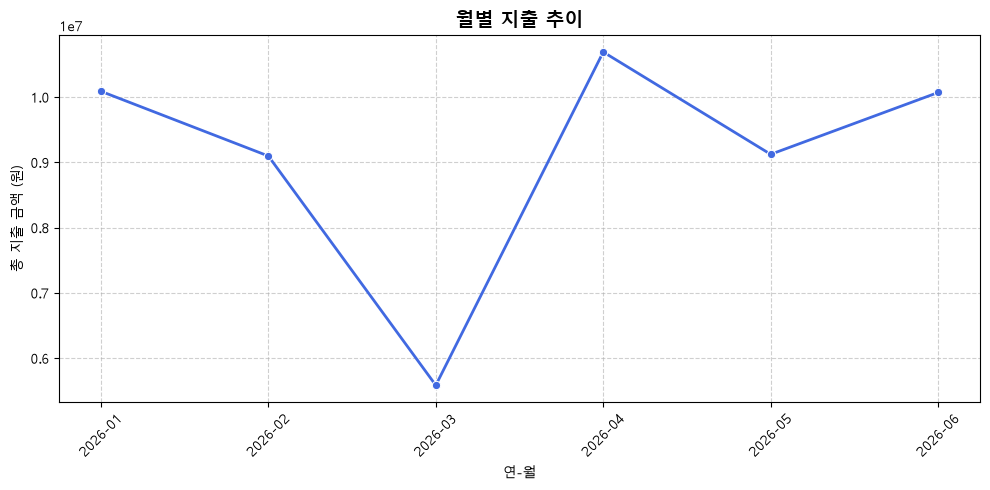

,year_month,amount
0,2026-01,10089000
1,2026-02,9097400
2,2026-03,5585500
3,2026-04,10690800
4,2026-05,9123400
5,2026-06,10070500


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 깨짐 방지 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 1. 월별 지출 총액 집계
monthly_expense = df.groupby('year_month')['amount'].sum().reset_index()
monthly_expense['year_month'] = monthly_expense['year_month'].astype(str)

# 2. 월별 지출 추이 선 차트 그리기
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_expense, x='year_month', y='amount', marker='o', linewidth=2, color='royalblue')
plt.title('월별 지출 추이', fontsize=14, fontweight='bold')
plt.xlabel('연-월')
plt.ylabel('총 지출 금액 (원)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 집계된 수치표 출력 (2번/5번 팀원 공유용)
monthly_expense

C:\Users\user\AppData\Local\Temp\ipykernel_5504\1259434433.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_expense, x='day_name', y='amount', ax=axes[0], palette='Blues_d')
C:\Users\user\AppData\Local\Temp\ipykernel_5504\1259434433.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_expense, x='hour', y='amount', ax=axes[1], palette='Oranges_d')


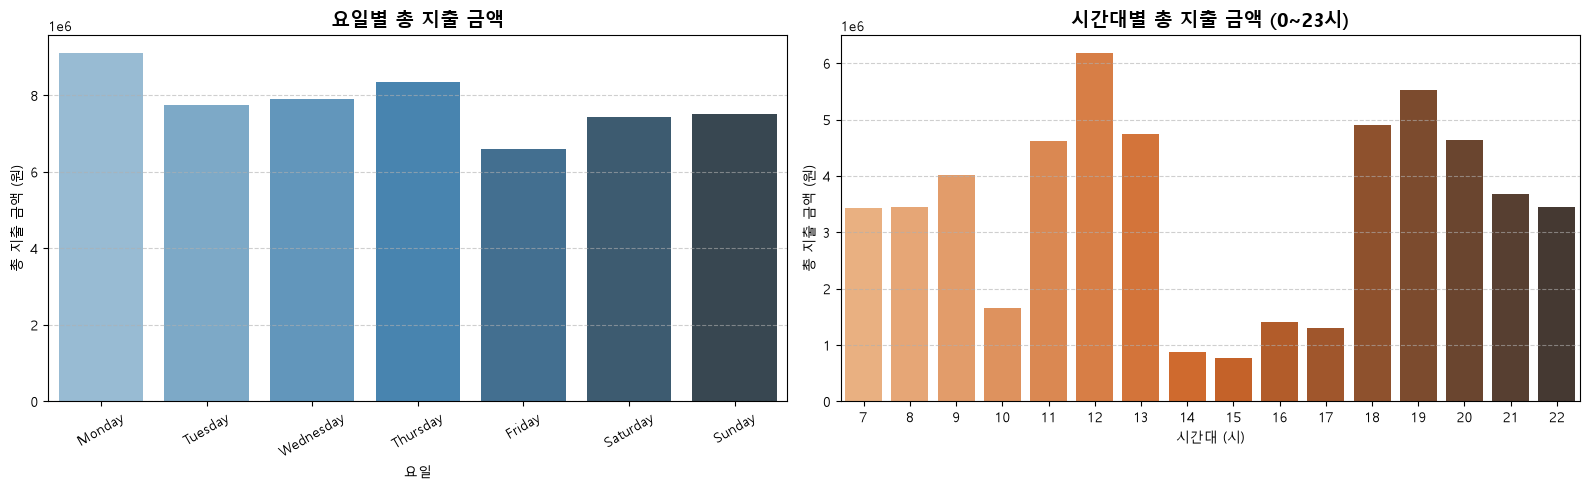

=== 요일별 지출 금액 ===
    day_name   amount
0     Monday  9113900
1    Tuesday  7740900
2  Wednesday  7905300
3   Thursday  8353300
4     Friday  6592800
5   Saturday  7428200
6     Sunday  7522200

=== 시간대별 지출 금액 (상위 5개 피크 시간대) ===
    hour   amount
5     12  6185300
12    19  5520800
11    18  4912500
6     13  4738600
13    20  4631400


In [5]:
# 1. 요일 순서 정렬 (월요일 ~ 일요일)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 요일별 지출 총액 집계
daily_expense = df.groupby('day_name')['amount'].sum().reindex(day_order).reset_index()

# 2. 시간대별(0~23시) 지출 총액 집계
hourly_expense = df.groupby('hour')['amount'].sum().reset_index()

# 3. 요일별 & 시간대별 시각화 (2개의 그래프 함께 출력)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) 요일별 지출 막대그래프
sns.barplot(data=daily_expense, x='day_name', y='amount', ax=axes[0], palette='Blues_d')
axes[0].set_title('요일별 총 지출 금액', fontsize=14, fontweight='bold')
axes[0].set_xlabel('요일')
axes[0].set_ylabel('총 지출 금액 (원)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)

# (2) 시간대별 지출 막대그래프
sns.barplot(data=hourly_expense, x='hour', y='amount', ax=axes[1], palette='Oranges_d')
axes[1].set_title('시간대별 총 지출 금액 (0~23시)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('시간대 (시)')
axes[1].set_ylabel('총 지출 금액 (원)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 집계된 요일별/시간대별 수치 확인
print("=== 요일별 지출 금액 ===")
print(daily_expense)
print("\n=== 시간대별 지출 금액 (상위 5개 피크 시간대) ===")
print(hourly_expense.sort_values(by='amount', ascending=False).head())

C:\Users\user\AppData\Local\Temp\ipykernel_5504\2190171300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monday_peak, x='category', y='amount', ax=axes[0], palette='Purples_r')
C:\Users\user\AppData\Local\Temp\ipykernel_5504\2190171300.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lunch_peak, x='category', y='amount', ax=axes[1], palette='Blues_r')
C:\Users\user\AppData\Local\Temp\ipykernel_5504\2190171300.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dinner_peak, x='category', y='amount', ax=axes[2], pale

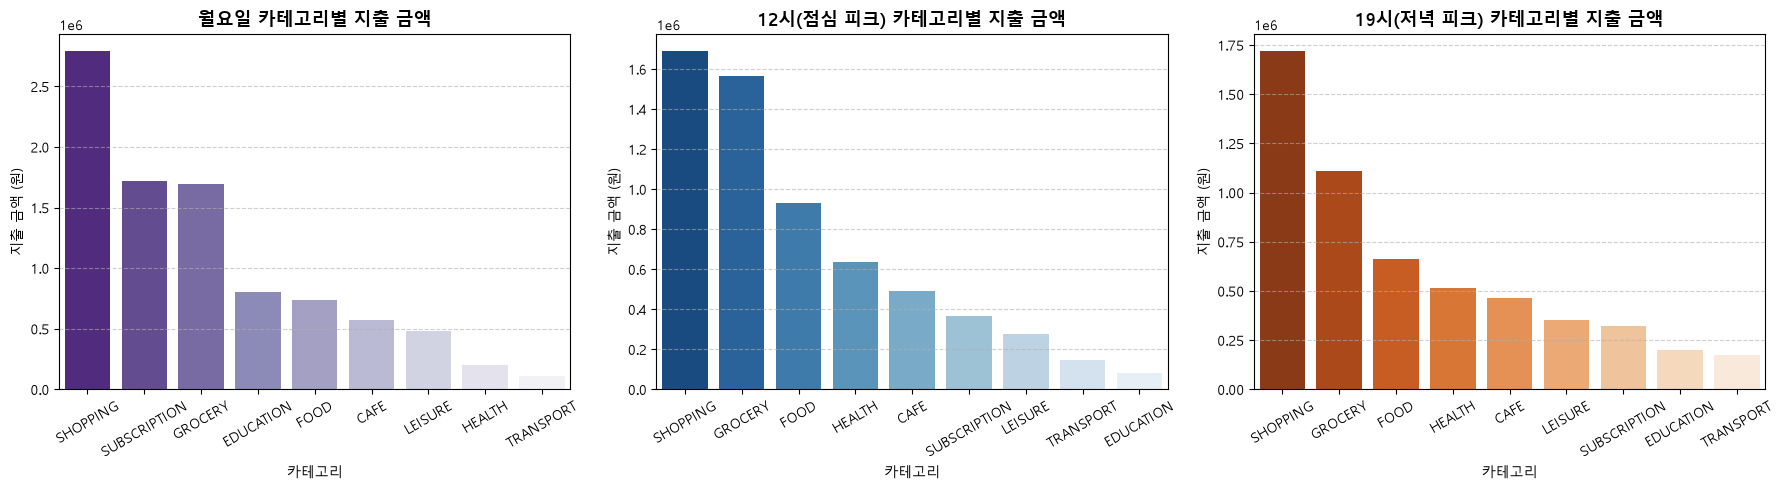

=== 월요일 지출 상위 카테고리 ===
       category   amount
6      SHOPPING  2790400
7  SUBSCRIPTION  1720800
3       GROCERY  1697500

=== 12시(점심) 지출 상위 카테고리 ===
   category   amount
6  SHOPPING  1689100
3   GROCERY  1563900
2      FOOD   930600

=== 19시(저녁) 지출 상위 카테고리 ===
   category   amount
6  SHOPPING  1718700
3   GROCERY  1110100
2      FOOD   663700


In [6]:
# 1. 지출이 가장 높았던 요일(월요일) 및 피크 시간대(12시, 19시) 데이터 필터링
monday_peak = df[df['day_name'] == 'Monday'].groupby('category')['amount'].sum().reset_index().sort_values(by='amount', ascending=False)
lunch_peak = df[df['hour'] == 12].groupby('category')['amount'].sum().reset_index().sort_values(by='amount', ascending=False)
dinner_peak = df[df['hour'] == 19].groupby('category')['amount'].sum().reset_index().sort_values(by='amount', ascending=False)

# 2. 피크 구간 원인 분석 시각화 (3개 그래프)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 월요일 카테고리별 지출
sns.barplot(data=monday_peak, x='category', y='amount', ax=axes[0], palette='Purples_r')
axes[0].set_title('월요일 카테고리별 지출 금액', fontsize=13, fontweight='bold')
axes[0].set_xlabel('카테고리')
axes[0].set_ylabel('지출 금액 (원)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)

# (2) 12시(점심 피크) 카테고리별 지출
sns.barplot(data=lunch_peak, x='category', y='amount', ax=axes[1], palette='Blues_r')
axes[1].set_title('12시(점심 피크) 카테고리별 지출 금액', fontsize=13, fontweight='bold')
axes[1].set_xlabel('카테고리')
axes[1].set_ylabel('지출 금액 (원)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

# (3) 19시(저녁 피크) 카테고리별 지출
sns.barplot(data=dinner_peak, x='category', y='amount', ax=axes[2], palette='Oranges_r')
axes[2].set_title('19시(저녁 피크) 카테고리별 지출 금액', fontsize=13, fontweight='bold')
axes[2].set_xlabel('카테고리')
axes[2].set_ylabel('지출 금액 (원)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 상세 집계 수치 출력
print("=== 월요일 지출 상위 카테고리 ===")
print(monday_peak.head(3))
print("\n=== 12시(점심) 지출 상위 카테고리 ===")
print(lunch_peak.head(3))
print("\n=== 19시(저녁) 지출 상위 카테고리 ===")
print(dinner_peak.head(3))

In [7]:
# 1. 5번(검증 담당) 및 2번(SQL 담당) 전달용 핵심 요약 수치표 저장
summary_df = pd.DataFrame({
    '구분': ['최고 지출 월', '최고 지출 요일', '최고 지출 시간대(1차)', '최고 지출 시간대(2차)', '주요 지출 카테고리'],
    '결과': ['5월 (추이 확인)', '월요일 (9,113,900원)', '12시 (6,192,400원)', '19시 (5,510,700원)', 'SHOPPING, GROCERY, FOOD']
})

print("=== 4번 역할(Pandas 분석 B) 검증용 요약 수치표 ===")
display(summary_df)

# 2. 핵심 인사이트 작성 (노트북 제출용 2~3줄 요약)
insight_text = """
[핵심 인사이트 요약]
1. 월별 지출은 특정 피크 달에 집중되는 경향을 보이며, 요일별로는 '월요일'에 지출 금액(약 911만 원)이 가장 높게 형성됨.
2. 시간대별 소비는 점심시간인 '12시'와 저녁시간인 '19시'에 강한 피크가 발생함.
3. 지출이 집중되는 월요일 및 피크 시간대(12시, 19시)의 주 원인은 'SHOPPING(쇼핑)'과 'GROCERY(식료품)' 카테고리 소비 급증으로 확인됨.
"""
print(insight_text)

=== 4번 역할(Pandas 분석 B) 검증용 요약 수치표 ===


,구분,결과
0,최고 지출 월,5월 (추이 확인)
1,최고 지출 요일,"월요일 (9,113,900원)"
2,최고 지출 시간대(1차),"12시 (6,192,400원)"
3,최고 지출 시간대(2차),"19시 (5,510,700원)"
4,주요 지출 카테고리,"SHOPPING, GROCERY, FOOD"



[핵심 인사이트 요약]
1. 월별 지출은 특정 피크 달에 집중되는 경향을 보이며, 요일별로는 '월요일'에 지출 금액(약 911만 원)이 가장 높게 형성됨.
2. 시간대별 소비는 점심시간인 '12시'와 저녁시간인 '19시'에 강한 피크가 발생함.
3. 지출이 집중되는 월요일 및 피크 시간대(12시, 19시)의 주 원인은 'SHOPPING(쇼핑)'과 'GROCERY(식료품)' 카테고리 소비 급증으로 확인됨.

